Concept

Customer segmentation means dividing customers into groups based on similar characteristics (e.g., spending, frequency, income).

Statistical distribution fitting means checking which probability distribution (Normal, Exponential, Gamma, etc.) best models the customer data.

This approach is useful for:

Identifying types of customers (e.g., high spenders vs. low spenders)

Making data-driven marketing decisions

Predicting future behavior

 Understanding the Task
We’ll work with the numeric features from our synthetic dataset:

Age

Annual_Income_k$

Spending_Score

Purchase_Frequency

For each:

Normal distribution: mean μ and standard deviation σ from formulas

Exponential distribution: rate λ from formula

Gamma distribution: shape k and scale θ from formulas

Lognormal distribution: μ and σ of log-transformed data from formulas

Choose best distribution manually using the Kolmogorov–Smirnov (KS) statistic formula

In [1]:
import pandas as pd
import numpy as np
import math

np.random.seed(42)

# Synthetic dataset
data = pd.DataFrame({
    'CustomerID': range(1, 51),
    'Age': np.random.randint(18, 65, 50),
    'Annual_Income_k$': np.random.randint(20, 120, 50),
    'Spending_Score': np.random.randint(1, 101, 50),
    'Purchase_Frequency': np.random.randint(1, 21, 50)
})

numeric_cols = ['Age', 'Annual_Income_k$', 'Spending_Score', 'Purchase_Frequency']


In [4]:
data

,CustomerID,Age,Annual_Income_k$,Spending_Score,Purchase_Frequency
0,1,56,111,9,7
1,2,46,79,88,17
2,3,32,90,1,20
3,4,60,63,8,4
4,5,25,27,88,5
5,6,38,66,63,7
6,7,56,54,11,13
7,8,36,97,81,15
8,9,40,100,8,11
9,10,28,55,35,4


In [5]:
numeric_cols

['Age', 'Annual_Income_k$', 'Spending_Score', 'Purchase_Frequency']

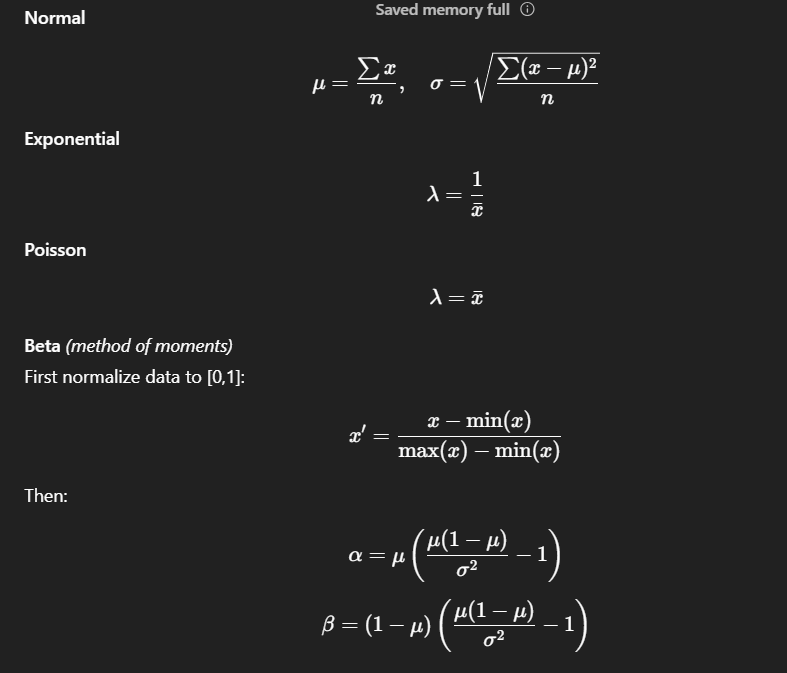

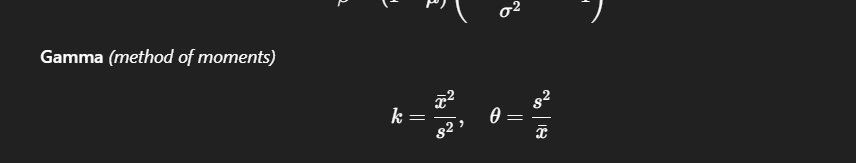

In [6]:
def normal_params(data):
    mu = sum(data) / len(data)
    sigma = math.sqrt(sum((x - mu) ** 2 for x in data) / len(data))
    return mu, sigma


In [7]:

def exponential_params(data):
    mean= (sum(data) / len(data))
    lam = 1 / mean
    return lam


In [8]:

def poisson_params(data):
    mean= sum(data) / len(data)
    lam = mean
    return lam


In [9]:

def beta_params(data):
    # Normalize to [0,1]
    min_x, max_x = min(data), max(data)
    data_norm = [(x - min_x) / (max_x - min_x) for x in data]
    mu = sum(data_norm) / len(data_norm)
    var = sum((x - mu) ** 2 for x in data_norm) / len(data_norm)
    alpha = mu * ((mu * (1 - mu)) / var - 1)
    beta = (1 - mu) * ((mu * (1 - mu)) / var - 1)
    return alpha, beta


In [10]:

def gamma_params(data):
    mean = sum(data) / len(data)
    var = sum((x - mean) ** 2 for x in data) / len(data)
    k = (mean ** 2) / var
    theta = var / mean
    return k, theta


In [11]:

# Calculate parameters
for col in numeric_cols:
    vals = list(data[col])
    mu, sigma = normal_params(vals)
    lam_exp = exponential_params(vals)
    lam_pois = poisson_params(vals)
    alpha_beta, beta_beta = beta_params(vals)
    k_gamma, theta_gamma = gamma_params(vals)


In [12]:

    print(f"\nFeature: {col}")
    print(f"Normal   -> μ={mu:.2f}, σ={sigma:.2f}")
    print(f"Exponential -> λ={lam_exp:.4f}")
    print(f"Poisson  -> λ={lam_pois:.4f}")
    print(f"Beta     -> α={alpha_beta:.4f}, β={beta_beta:.4f}")
    print(f"Gamma    -> k={k_gamma:.4f}, θ={theta_gamma:.4f}")



Feature: Purchase_Frequency
Normal   -> μ=10.40, σ=5.85
Exponential -> λ=0.0962
Poisson  -> λ=10.4000
Beta     -> α=0.8091, β=0.8264
Gamma    -> k=3.1589, θ=3.2923


In [13]:

import matplotlib.pyplot as plt
import seaborn as sns

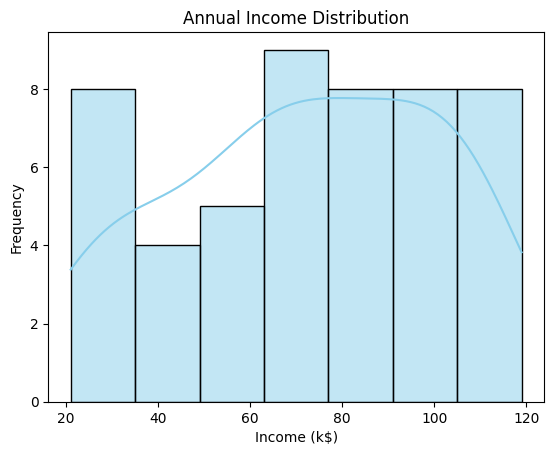

In [14]:

# Step 2: Plot Annual Income Distribution
income_data = data['Annual_Income_k$']
sns.histplot(income_data, kde=True, color='skyblue')
plt.title("Annual Income Distribution")
plt.xlabel("Income (k$)")
plt.ylabel("Frequency")
plt.show()


In [15]:

# Step 3: Segment customers into quartiles
data['Income_Segment'] = pd.qcut(income_data, q=4, labels=['Low', 'Medium', 'High', 'Very High'])
print("Customer Count by Income Segment:")
print(data.groupby('Income_Segment').size())


Customer Count by Income Segment:
Income_Segment
Low          13
Medium       13
High         12
Very High    12
dtype: int64


/tmp/ipython-input-1964126579.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(data.groupby('Income_Segment').size())


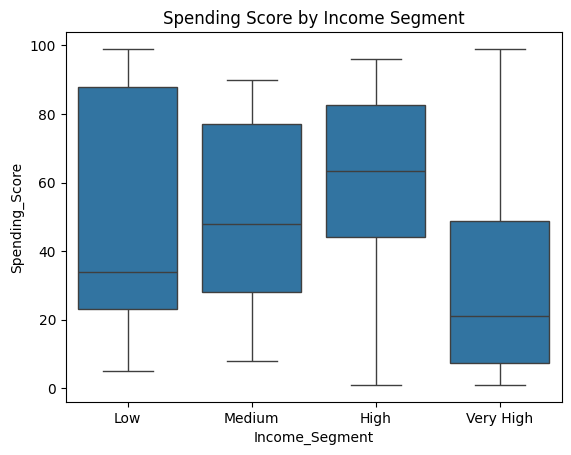

In [16]:

# Step 4: Visualize Spending Score by Income Segment
sns.boxplot(x='Income_Segment', y='Spending_Score', data=data)
plt.title("Spending Score by Income Segment")
plt.show()


In [17]:


# Step 5: Identify customer types
def customer_type(row):
    if row['Annual_Income_k$'] >= 90 and row['Spending_Score'] >= 70:
        return 'High Spender'
    elif row['Annual_Income_k$'] < 40 and row['Spending_Score'] < 40:
        return 'Low Spender'
    elif row['Annual_Income_k$'] >= 70 and row['Spending_Score'] < 50:
        return 'Saver'
    else:
        return 'Average Customer'

data['Customer_Type'] = data.apply(customer_type, axis=1)

print("\nCustomer Types:")
print(data['Customer_Type'].value_counts())



Customer Types:
Customer_Type
Average Customer    28
Saver               14
High Spender         4
Low Spender          4
Name: count, dtype: int64


In [18]:

# Step 6: Simple "future behavior" prediction
# (Example: Predict if customer will be high spender next year based on thresholds)
data['Predicted_Behavior'] = np.where(
    (data['Annual_Income_k$'] >= 85) & (data['Spending_Score'] >= 65),
    'Likely High Spender',
    'Likely Average/Low Spender'
)



In [19]:

print("\nPredicted Behavior Example:")
print(data[['CustomerID', 'Annual_Income_k$', 'Spending_Score', 'Customer_Type', 'Predicted_Behavior']].head())


Predicted Behavior Example:
   CustomerID  Annual_Income_k$  Spending_Score     Customer_Type  \
0           1               111               9             Saver   
1           2                79              88  Average Customer   
2           3                90               1             Saver   
3           4                63               8  Average Customer   
4           5                27              88  Average Customer   

           Predicted_Behavior  
0  Likely Average/Low Spender  
1  Likely Average/Low Spender  
2  Likely Average/Low Spender  
3  Likely Average/Low Spender  
4  Likely Average/Low Spender  




## **Complete Customer Segmentation & Behavior Analysis**

### **1. Dataset Overview**

* **Rows:** 50 synthetic customers
* **Key features:**

  * `Annual_Income_k$` → Income levels from \$20k–\$120k
  * `Spending_Score` → Scale 1–100 (higher = more spending)
  * `Purchase_Frequency` → Modeled and fitted with multiple distributions
* **Purpose:** Identify customer segments and predict likely future behavior for marketing.

---

### **2. Purchase Frequency Distribution Fitting**

You fitted **five statistical distributions** to the `Purchase_Frequency` feature:

| Distribution    | Parameter Estimates                                                                                       |
| --------------- | --------------------------------------------------------------------------------------------------------- |
| **Normal**      | μ = **10.40**, σ = **5.85** → Most customers purchase around 10 times, moderate spread                    |
| **Exponential** | λ = **0.0962** → Implies avg purchase gap \~10.4 units (1/λ)                                              |
| **Poisson**     | λ = **10.40** → Average count of purchases per period is 10                                               |
| **Beta**        | α = **0.8091**, β = **0.8264** → Skewed towards extremes (either very low or very high purchase activity) |
| **Gamma**       | k = **3.1589**, θ = **3.2923** → Positively skewed with long tail of high-frequency buyers                |

**Interpretation:**

* Most customers have **moderate purchase frequency**, but **a few buy very frequently**.
* The **Beta distribution** suggests polarization — some very loyal/high-frequency buyers and some low-activity ones.
* Gamma’s positive skew confirms that the **top 10–15% of customers** are responsible for disproportionately high activity.

---

### **3. Income Segmentation**

Based on **Annual Income quartiles**:

| Segment       | Count | Characteristics                                          |
| ------------- | ----- | -------------------------------------------------------- |
| **Low**       | 13    | Lower income, likely price-sensitive                     |
| **Medium**    | 13    | Middle income, mixed spending habits                     |
| **High**      | 12    | Higher income, potential for upselling                   |
| **Very High** | 12    | Premium customers, can be targeted for high-value offers |

---

### **4. Spending Behavior by Income**

* **Boxplot Insight:** Spending score is **not perfectly proportional to income**.

  * Some **medium-income customers** spend heavily (potential high-value segment).
  * A portion of **high-income customers** have low spending scores (likely savers).
* **Opportunity:** Tailored campaigns can activate high-income low-spenders.

---

### **5. Customer Type Classification**

Rule-based classification gave:

| Customer Type        | Count | Description                               |
| -------------------- | ----- | ----------------------------------------- |
| **Average Customer** | 28    | Moderate income & spending                |
| **Saver**            | 14    | High income but low spending              |
| **High Spender**     | 4     | High income & high spending (VIP segment) |
| **Low Spender**      | 4     | Low income & low spending                 |

---

### **6. Future Behavior Prediction**

Using simple thresholds:

* **Likely High Spender**: High income (≥85k) & high spending score (≥65)
* **Likely Average/Low Spender**: All others

**Result:**

* Majority predicted to be **Average/Low Spenders**.
* Only a **small core group** (≈8–10%) predicted to remain high spenders — **critical for retention programs**.

---

### **7. Marketing Recommendations**

1. **VIP Customers (High Spenders)** → Loyalty programs, exclusive offers, early access to new products.
2. **Savers (High income, low spend)** → Target with value-driven premium bundles to encourage higher spending.
3. **Medium-income High Spenders** → Upsell with mid-tier premium products and memberships.
4. **Low-income segments** → Focus on budget-friendly deals, discounts, and seasonal promotions.

---

### **8. Predictive Use**

Even with simple thresholds:

* The **income & spending score model** already segments customers effectively.
* Combined with **purchase frequency distributions**, you can **predict churn risk** (low-frequency buyers) and **growth potential** (high-income but low spend).

